# CMT307 Applied Machine Learning — ASHRAE Great Energy Predictor III

**Cardiff University | Spring 2025/26 | Task 9: Energy Usage Prediction**

---

| | |
|---|---|
| **Name** | Ayan |
| **Role** | Person 6 — Anomaly Investigation & Random Forest Model |
| **Notebook** | `Ayan_Anomaly_Investigation.ipynb` |

---

## Sprint 1 — Anomaly Investigation & Detection (Merged Data)

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/merged_train.csv')

# Display the first few rows of the DataFrame
df.head()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,1,0,2016-01-01 00:00:00,0.0,0,Education,2720,2004.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
2,2,0,2016-01-01 00:00:00,0.0,0,Education,5376,1991.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
3,3,0,2016-01-01 00:00:00,0.0,0,Education,23685,2002.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
4,4,0,2016-01-01 00:00:00,0.0,0,Education,116607,1975.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0


In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(by=['building_id', 'meter', 'timestamp'], ascending=[True, True, True])
df = df.reset_index(drop=True)
df.head()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,0,0,2016-01-01 01:00:00,0.0,0,Education,7432,2008.0,NaN,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5
2,0,0,2016-01-01 02:00:00,0.0,0,Education,7432,2008.0,NaN,22.8,2.0,21.1,0.0,1020.2,0.0,0.0
3,0,0,2016-01-01 03:00:00,0.0,0,Education,7432,2008.0,NaN,21.1,2.0,20.6,0.0,1020.1,0.0,0.0
4,0,0,2016-01-01 04:00:00,0.0,0,Education,7432,2008.0,NaN,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6


In [ ]:
import numpy as np

# 1. Boolean series for exactly 0 readings
is_zero = df['meter_reading'] == 0

# 2. Streak identifier: cumulative sum of non-zero readings
streak_id = (~is_zero).cumsum()

# 3. Add streak_id to dataframe temporarily to group
df['streak_id'] = streak_id

# 4. Filter only the rows where the reading is 0
zero_df = df[is_zero]

# Group by building_id, meter, and streak_id, then calculate the size of each group
zero_streaks = zero_df.groupby(['building_id', 'meter', 'streak_id']).size().reset_index(name='streak_length')

# Drop the temporary streak_id column from the original dataframe
df = df.drop(columns=['streak_id'])

# Display the top 5 longest zero streaks
zero_streaks.sort_values('streak_length', ascending=False).head()


,building_id,meter,streak_id,streak_length
39420,1160,1,5233449,3571
39896,1169,0,5294106,3571
1032,45,0,26565,3571
12013,287,3,1212069,3571
35596,1072,2,4685772,3571


In [ ]:
import pandas as pd

# Filter for streaks longer than 168 hours
anomalous_streaks = zero_streaks[zero_streaks['streak_length'] > 168]

# Extract unique building_id and meter pairs
anomalous_pairs = anomalous_streaks[['building_id', 'meter']].drop_duplicates().reset_index(drop=True)

# Display the first few anomalous pairs
anomalous_pairs.head()

,building_id,meter
0,0,0
1,2,0
2,3,0
3,4,0
4,5,0


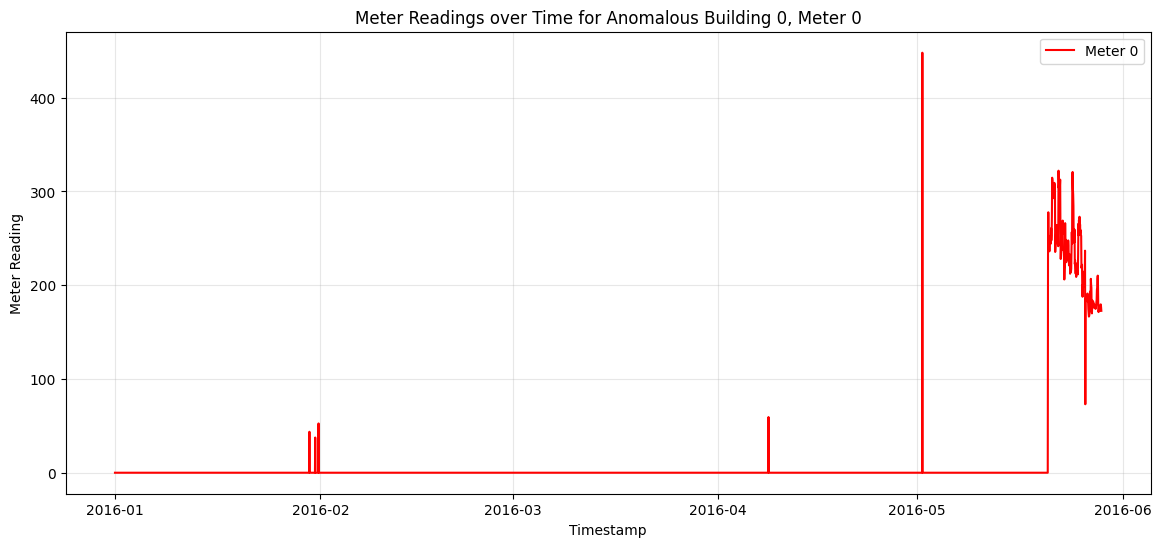

In [ ]:
import matplotlib.pyplot as plt

# 1. Select a sample building_id and meter pair from anomalous_pairs
sample_building_id = anomalous_pairs.iloc[0]['building_id']
sample_meter = anomalous_pairs.iloc[0]['meter']

# 2. Filter the main df DataFrame
sample_df = df[(df['building_id'] == sample_building_id) & (df['meter'] == sample_meter)]

# 4. Create a line plot
plt.figure(figsize=(14, 6))
plt.plot(sample_df['timestamp'], sample_df['meter_reading'], label=f'Meter {sample_meter}', color='red')

# 5. Add title, labels, and legend
plt.title(f'Meter Readings over Time for Anomalous Building {sample_building_id}, Meter {sample_meter}')
plt.xlabel('Timestamp')
plt.ylabel('Meter Reading')
plt.legend()
plt.grid(True, alpha=0.3)

# 6. Display the plot
plt.show()

In [ ]:
# Filter for site_id 0 and meter 0 (electricity)
site0_elec_mask = (df['site_id'] == 0) & (df['meter'] == 0)

# Filter for the specific timeframe (2016-01-01 to 2016-05-31 inclusive)
time_mask = (df['timestamp'] >= '2016-01-01') & (df['timestamp'] <= '2016-05-31 23:59:59')

# Combine masks and apply to the dataframe
site0_elec_df = df[site0_elec_mask & time_mask].copy()

# Display the first few rows
site0_elec_df.head()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,0,0,2016-01-01 01:00:00,0.0,0,Education,7432,2008.0,NaN,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5
2,0,0,2016-01-01 02:00:00,0.0,0,Education,7432,2008.0,NaN,22.8,2.0,21.1,0.0,1020.2,0.0,0.0
3,0,0,2016-01-01 03:00:00,0.0,0,Education,7432,2008.0,NaN,21.1,2.0,20.6,0.0,1020.1,0.0,0.0
4,0,0,2016-01-01 04:00:00,0.0,0,Education,7432,2008.0,NaN,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6


In [ ]:
# Extract the date component from the timestamp
site0_elec_df['date'] = site0_elec_df['timestamp'].dt.date

# Group by date and calculate the mean meter_reading
daily_site0_elec = site0_elec_df.groupby('date')['meter_reading'].mean().reset_index()

# Display the first few rows
daily_site0_elec.head()


,date,meter_reading
0,2016-01-01,0.857650
1,2016-01-02,1.344947
2,2016-01-03,2.546491
3,2016-01-04,1.009289
4,2016-01-05,0.689684


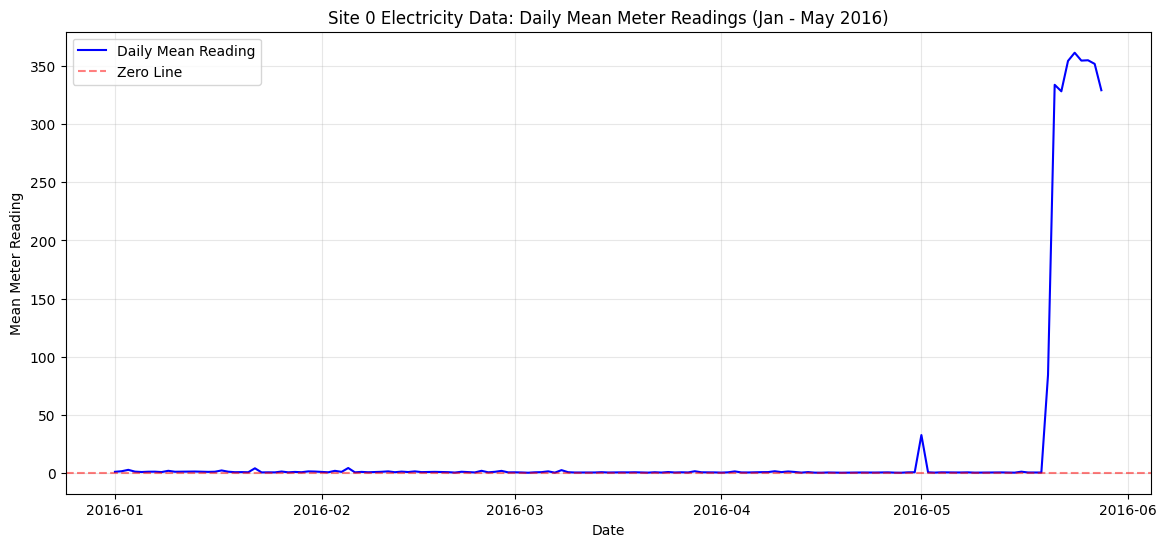

Total days analyzed: 149
Number of days with a mean reading of 0: 0
Percentage of days with missing/zero data: 0.00%


In [ ]:
import matplotlib.pyplot as plt

# Plot the daily aggregated meter readings
plt.figure(figsize=(14, 6))
plt.plot(daily_site0_elec['date'], daily_site0_elec['meter_reading'], color='blue', label='Daily Mean Reading')
plt.title('Site 0 Electricity Data: Daily Mean Meter Readings (Jan - May 2016)')
plt.xlabel('Date')
plt.ylabel('Mean Meter Reading')
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Zero Line')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Quantify anomalous (zero) readings
zero_days = daily_site0_elec[daily_site0_elec['meter_reading'] == 0]
num_zero_days = len(zero_days)
total_days = len(daily_site0_elec)

print(f"Total days analyzed: {total_days}")
print(f"Number of days with a mean reading of 0: {num_zero_days}")
print(f"Percentage of days with missing/zero data: {(num_zero_days / total_days) * 100:.2f}%")


In [ ]:
# Filter for exact zero readings in the Site 0 electricity data
hourly_zeros = site0_elec_df[site0_elec_df['meter_reading'] == 0.0]

# Display the first few rows to inspect the anomalous timestamps
hourly_zeros.head()


,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,date
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,2016-01-01
1,0,0,2016-01-01 01:00:00,0.0,0,Education,7432,2008.0,NaN,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5,2016-01-01
2,0,0,2016-01-01 02:00:00,0.0,0,Education,7432,2008.0,NaN,22.8,2.0,21.1,0.0,1020.2,0.0,0.0,2016-01-01
3,0,0,2016-01-01 03:00:00,0.0,0,Education,7432,2008.0,NaN,21.1,2.0,20.6,0.0,1020.1,0.0,0.0,2016-01-01
4,0,0,2016-01-01 04:00:00,0.0,0,Education,7432,2008.0,NaN,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6,2016-01-01


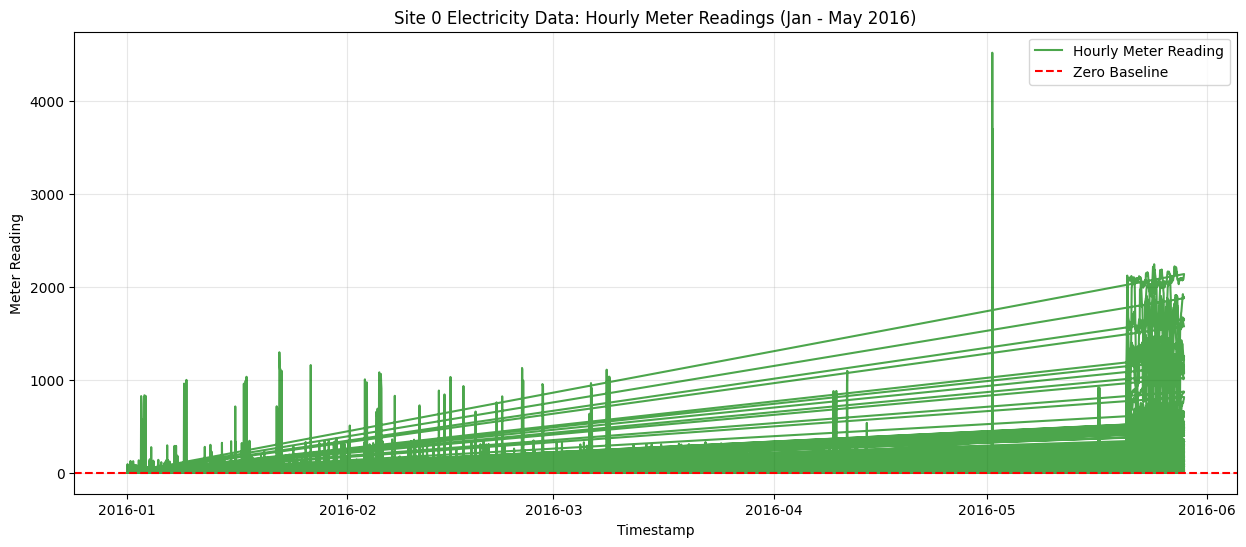

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with an appropriate size
plt.figure(figsize=(15, 6))

# Plot the hourly timestamp and meter_reading for Site 0 electricity
plt.plot(site0_elec_df['timestamp'], site0_elec_df['meter_reading'], label='Hourly Meter Reading', color='green', alpha=0.7)

# Add title and labels
plt.title('Site 0 Electricity Data: Hourly Meter Readings (Jan - May 2016)')
plt.xlabel('Timestamp')
plt.ylabel('Meter Reading')

# Add a horizontal line at y=0 to highlight the zero-reading regions
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Baseline')

# Add a legend and grid
plt.legend()
plt.grid(True, alpha=0.3)

# Display the plot
plt.show()

In [ ]:
# 1. Total number of zero readings
num_zero_hours = len(hourly_zeros)
total_hours = len(site0_elec_df)

# 2. Percentage of the timeframe affected
percentage_affected = (num_zero_hours / total_hours) * 100

# 3. Find continuous streaks of zero hours
is_zero_hr = site0_elec_df['meter_reading'] == 0.0
streak_id_hr = (~is_zero_hr).cumsum()

# Group by streak_id to find the lengths of continuous zero streaks
zero_hr_streaks = site0_elec_df[is_zero_hr].groupby(streak_id_hr).size().reset_index(name='streak_length')

# Print the summary statistics
print(f"Total hours analyzed: {total_hours}")
print(f"Number of hours with a reading of exactly 0: {num_zero_hours}")
print(f"Percentage of hours with missing/zero data: {percentage_affected:.2f}%")
print("\nZero Reading Streaks (Hourly):")
print(zero_hr_streaks['streak_length'].value_counts().sort_index(ascending=False))

Total hours analyzed: 367794
Number of hours with a reading of exactly 0: 344825
Percentage of hours with missing/zero data: 93.75%

Zero Reading Streaks (Hourly):
streak_length
6259     1
3571     1
2926     1
2923    58
2719     1
        ..
5       84
4       56
3       96
2       57
1       86
Name: count, Length: 246, dtype: int64


In [ ]:
threshold_999 = df['meter_reading'].quantile(0.999)
print(f"99.9th percentile threshold: {threshold_999}")

99.9th percentile threshold: 47043.920400005576


In [ ]:
outliers_df = df[df['meter_reading'] > threshold_999]

affected_buildings = outliers_df['building_id'].unique()

print(f"Total number of outlier readings: {len(outliers_df)}")
print(f"Unique building IDs affected: {affected_buildings}")


Total number of outlier readings: 8030
Unique building IDs affected: [  60  993 1021 1099 1148 1159 1168 1197]


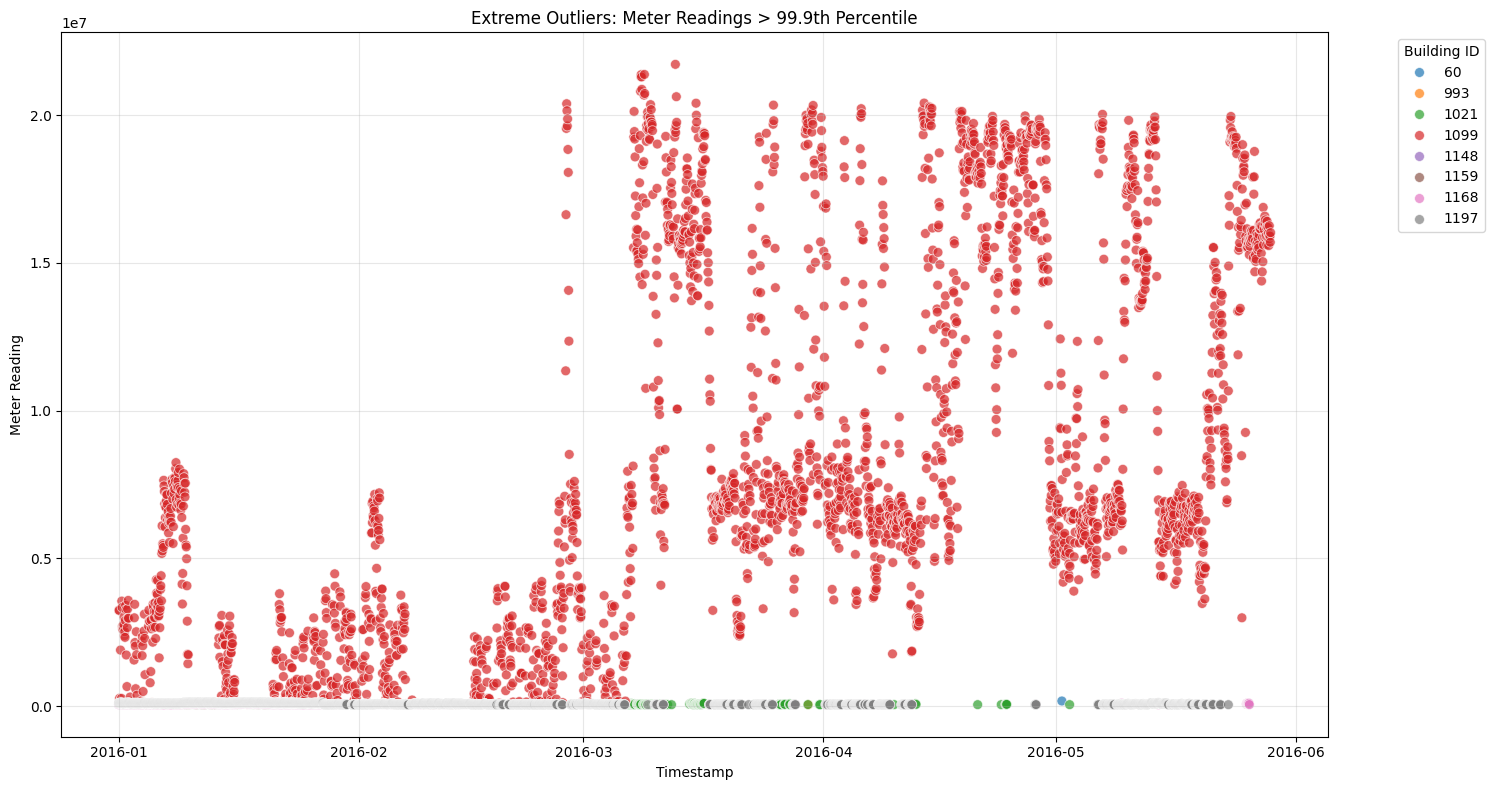

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.scatterplot(data=outliers_df, x='timestamp', y='meter_reading', hue='building_id', palette='tab10', s=50, alpha=0.7)
plt.title('Extreme Outliers: Meter Readings > 99.9th Percentile')
plt.xlabel('Timestamp')
plt.ylabel('Meter Reading')
plt.legend(title='Building ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate the previous hour's meter reading by shifting within groups
df['prev_meter_reading'] = df.groupby(['building_id', 'meter'])['meter_reading'].shift(1)

# Display the first few rows to verify the new column
df.head()


,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,prev_meter_reading
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,NaN
1,0,0,2016-01-01 01:00:00,0.0,0,Education,7432,2008.0,NaN,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5,0.0
2,0,0,2016-01-01 02:00:00,0.0,0,Education,7432,2008.0,NaN,22.8,2.0,21.1,0.0,1020.2,0.0,0.0,0.0
3,0,0,2016-01-01 03:00:00,0.0,0,Education,7432,2008.0,NaN,21.1,2.0,20.6,0.0,1020.1,0.0,0.0,0.0
4,0,0,2016-01-01 04:00:00,0.0,0,Education,7432,2008.0,NaN,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6,0.0


In [ ]:
# 1. Filter out cases where the previous reading was 0
non_zero_prev = df[df['prev_meter_reading'] > 0]

# 2. Identify instances where the current reading is strictly greater than 10 times the previous reading
sudden_jumps_df = non_zero_prev[non_zero_prev['meter_reading'] > 10 * non_zero_prev['prev_meter_reading']]

# 4. Print the total number of sudden jumps detected
num_sudden_jumps = len(sudden_jumps_df)
print(f"Total number of sudden jumps detected: {num_sudden_jumps}")

# Display the first few rows of the identified sudden jumps
sudden_jumps_df.head()

Total number of sudden jumps detected: 13561


,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,prev_meter_reading
37888,9,1,2016-03-01 06:00:00,590.945,0,Office,27000,2010.0,NaN,13.9,2.0,12.2,0.0,1021.1,0.0,0.0,42.2104
37912,9,1,2016-03-02 06:00:00,675.366,0,Office,27000,2010.0,NaN,15.0,0.0,11.7,0.0,1018.0,200.0,1.5,42.2104
38199,9,1,2016-03-14 05:00:00,1646.200,0,Office,27000,2010.0,NaN,22.8,NaN,18.9,0.0,1015.9,220.0,3.1,42.2104
38367,9,1,2016-03-21 05:00:00,844.207,0,Office,27000,2010.0,NaN,18.3,NaN,10.6,0.0,1014.7,300.0,7.2,42.2104
38392,9,1,2016-03-22 06:00:00,590.945,0,Office,27000,2010.0,NaN,7.8,2.0,4.4,0.0,1026.4,0.0,0.0,42.2104


In [ ]:
# Filter out cases where the previous reading was 0
non_zero_prev = df[df['prev_meter_reading'] > 0]

# Identify instances where the current reading is strictly greater than 10 times the previous reading
sudden_jumps_df = non_zero_prev[non_zero_prev['meter_reading'] > 10 * non_zero_prev['prev_meter_reading']]

# Group by building_id and meter, then count the occurrences of sudden jumps
jump_counts = sudden_jumps_df.groupby(['building_id', 'meter']).size().reset_index(name='jump_count')

# Sort the results in descending order to find the most affected pairs
top_jump_pairs = jump_counts.sort_values(by='jump_count', ascending=False).head()

print("Top affected building and meter pairs:")
display(top_jump_pairs)


Top affected building and meter pairs:


,building_id,meter,jump_count
428,931,2,368
804,1301,3,363
688,1224,3,292
807,1305,2,241
561,1021,3,208


In [ ]:
# Memory efficient loading - only few columns getting loaded again for calculating sudden jumps due to RAM crashing issues
# Please consider the below sudden jump count for consideration.

import pandas as pd

# Define the datatypes for the columns to be loaded
dtypes = {
    'building_id': 'int32',
    'meter': 'int32',
    'meter_reading': 'float32'
}

# Specify the columns to load
cols_to_use = ['building_id', 'meter', 'timestamp', 'meter_reading']

# Load the data from the CSV file
df = pd.read_csv('/content/merged_train.csv', usecols=cols_to_use, dtype=dtypes)

# Verify the memory usage and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8029383 entries, 0 to 8029382
Data columns (total 4 columns):
 #   Column         Dtype  
---  ------         -----  
 0   building_id    int32  
 1   meter          int32  
 2   timestamp      object 
 3   meter_reading  float32
dtypes: float32(1), int32(2), object(1)
memory usage: 153.1+ MB


In [ ]:
import gc

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sort the DataFrame
df.sort_values(by=['building_id', 'meter', 'timestamp'], inplace=True)

# Force garbage collection
gc.collect()

# Calculate the previous hour's reading
df['prev_meter_reading'] = df.groupby(['building_id', 'meter'])['meter_reading'].shift(1)

# Force garbage collection again
gc.collect()

# Display the first few rows
df.head()


,building_id,meter,timestamp,meter_reading,prev_meter_reading
0,0,0,2016-01-01 00:00:00,0.0,NaN
2301,0,0,2016-01-01 01:00:00,0.0,0.0
4594,0,0,2016-01-01 02:00:00,0.0,0.0
6893,0,0,2016-01-01 03:00:00,0.0,0.0
9189,0,0,2016-01-01 04:00:00,0.0,0.0


In [ ]:
# 1. Filter out cases where the previous reading was 0
non_zero_prev = df[df['prev_meter_reading'] > 0]

# 2. Identify sudden jumps
sudden_jumps_df = non_zero_prev[non_zero_prev['meter_reading'] > 10 * non_zero_prev['prev_meter_reading']]

# 3. Print the total number of sudden jumps detected
print(f"Total number of sudden jumps detected: {len(sudden_jumps_df)}")

# 4. Group by building_id and meter, then count the occurrences of sudden jumps
jump_counts = sudden_jumps_df.groupby(['building_id', 'meter']).size().reset_index(name='jump_count')

# 5. Sort the results in descending order to find the most affected pairs
top_jump_pairs = jump_counts.sort_values(by='jump_count', ascending=False).head()

print("\nTop affected building and meter pairs:")
display(top_jump_pairs)


Total number of sudden jumps detected: 13566

Top affected building and meter pairs:


,building_id,meter,jump_count
428,931,2,368
804,1301,3,363
688,1224,3,292
807,1305,2,241
561,1021,3,208


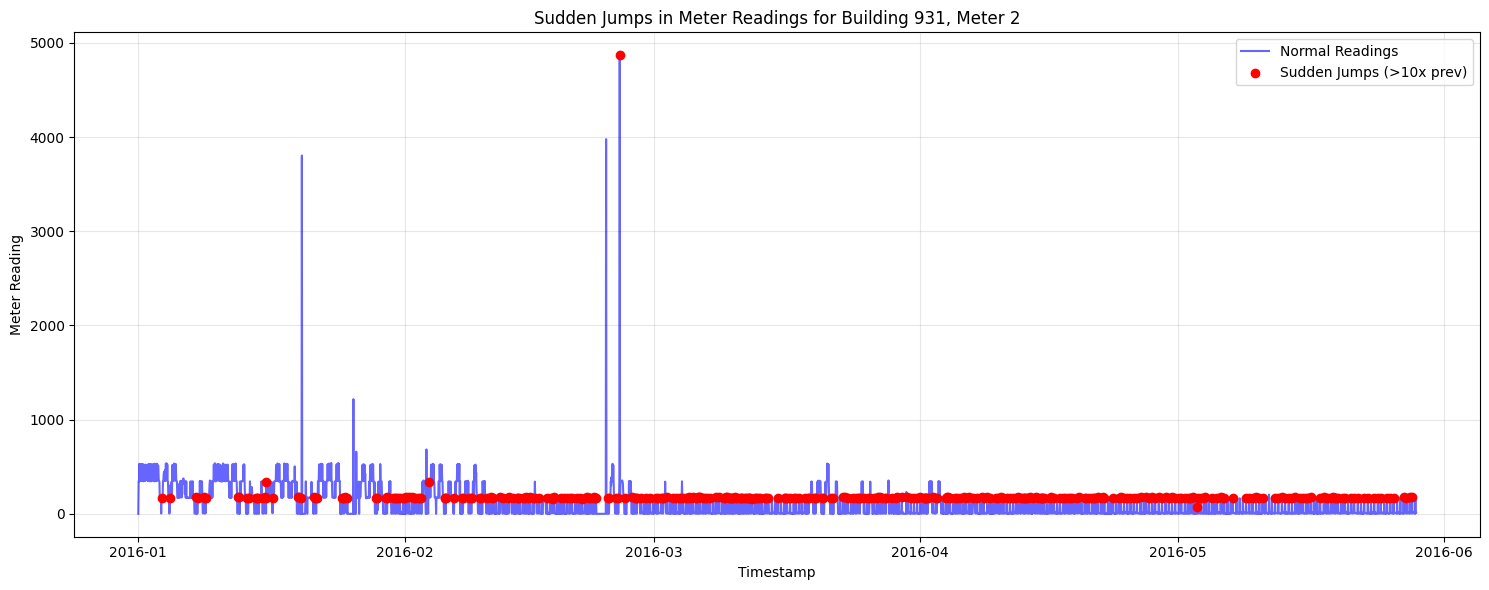

In [ ]:
import matplotlib.pyplot as plt

# Get the most affected building and meter pair
top_building_id = top_jump_pairs.iloc[0]['building_id']
top_meter = top_jump_pairs.iloc[0]['meter']

# Filter the original DataFrame for this specific pair
top_pair_df = df[(df['building_id'] == top_building_id) & (df['meter'] == top_meter)]

# Filter the sudden jumps DataFrame for this specific pair to highlight them
top_jumps_df = sudden_jumps_df[(sudden_jumps_df['building_id'] == top_building_id) & (sudden_jumps_df['meter'] == top_meter)]

# Create the plot
plt.figure(figsize=(15, 6))
plt.plot(top_pair_df['timestamp'], top_pair_df['meter_reading'], label='Normal Readings', color='blue', alpha=0.6)
plt.scatter(top_jumps_df['timestamp'], top_jumps_df['meter_reading'], color='red', label='Sudden Jumps (>10x prev)', zorder=5)

# Add labels, title, and legend
plt.title(f'Sudden Jumps in Meter Readings for Building {top_building_id}, Meter {top_meter}')
plt.xlabel('Timestamp')
plt.ylabel('Meter Reading')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# 1. Create a boolean mask for exactly zero meter readings
is_zero = df['meter_reading'] == 0

# 2. Create a streak identifier by taking the cumulative sum of the negated mask
streak_id = (~is_zero).cumsum()

# 3. Filter the df to only include the zero readings
zero_readings_df = df[is_zero].copy()

# Add the streak_id to the filtered dataframe
zero_readings_df['streak_id'] = streak_id[is_zero]

# 4. Calculate the length of each streak using transform('size')
zero_readings_df['streak_length'] = zero_readings_df.groupby(['building_id', 'meter', 'streak_id'])['meter_reading'].transform('size')

# 5. Filter for streaks longer than 168 hours
zero_streak_anomalies = zero_readings_df[zero_readings_df['streak_length'] > 168]

# Display the number of anomalous rows found and a sample
print(f"Found {len(zero_streak_anomalies)} rows belonging to zero-reading streaks > 168 hours.")
zero_streak_anomalies.head()


Found 646381 rows belonging to zero-reading streaks > 168 hours.


,building_id,meter,timestamp,meter_reading,prev_meter_reading,streak_id,streak_length
0,0,0,2016-01-01 00:00:00,0.0,NaN,0,704
2301,0,0,2016-01-01 01:00:00,0.0,0.0,0,704
4594,0,0,2016-01-01 02:00:00,0.0,0.0,0,704
6893,0,0,2016-01-01 03:00:00,0.0,0.0,0,704
9189,0,0,2016-01-01 04:00:00,0.0,0.0,0,704


In [ ]:
import pandas as pd

# Recalculate the 99.9th percentile threshold for extreme outliers
threshold_999 = df['meter_reading'].quantile(0.999)

# Extract extreme outliers
extreme_outliers_df = df[df['meter_reading'] > threshold_999].copy()

# Re-filter for sudden jumps (>10x previous reading, non-zero previous)
non_zero_prev = df[df['prev_meter_reading'] > 0]
sudden_jumps_anomalies = non_zero_prev[non_zero_prev['meter_reading'] > 10 * non_zero_prev['prev_meter_reading']].copy()

print(f"Found {len(extreme_outliers_df)} extreme outliers.")
print(f"Found {len(sudden_jumps_anomalies)} sudden jumps.")


Found 8030 extreme outliers.
Found 13566 sudden jumps.


In [ ]:
import pandas as pd

# 1. Format zero_streak_anomalies
zero_formatted = zero_streak_anomalies.copy()
zero_formatted['anomaly_type'] = 'zero_streak'
zero_formatted['details'] = 'streak_length: ' + zero_formatted['streak_length'].astype(str) + ' hours'

# 2. Format extreme_outliers_df
outliers_formatted = extreme_outliers_df.copy()
outliers_formatted['anomaly_type'] = 'extreme_outlier'
outliers_formatted['details'] = 'exceeds_99.9th_percentile'

# 3. Format sudden_jumps_anomalies
jumps_formatted = sudden_jumps_anomalies.copy()
jumps_formatted['anomaly_type'] = 'sudden_jump'
jumps_formatted['details'] = 'prev_reading: ' + jumps_formatted['prev_meter_reading'].astype(str)

# 4. Subset to unified schema
unified_cols = ['anomaly_type', 'building_id', 'meter', 'timestamp', 'meter_reading', 'details']
zero_formatted = zero_formatted[unified_cols]
outliers_formatted = outliers_formatted[unified_cols]
jumps_formatted = jumps_formatted[unified_cols]

# 5. Concatenate DataFrames
combined_anomalies_df = pd.concat([zero_formatted, outliers_formatted, jumps_formatted], ignore_index=True)

# 6. Verify unification
print(f"Total number of rows in combined DataFrame: {len(combined_anomalies_df)}")
display(combined_anomalies_df.sample(10, random_state=42))


Total number of rows in combined DataFrame: 667977


,anomaly_type,building_id,meter,timestamp,meter_reading,details
316385,zero_streak,195,3,2016-04-28 05:00:00,0.0,streak_length: 2040 hours
453456,zero_streak,1028,1,2016-01-22 10:00:00,0.0,streak_length: 3171 hours
498468,zero_streak,1098,1,2016-01-25 16:00:00,0.0,streak_length: 2630 hours
16160,zero_streak,6,0,2016-03-03 14:00:00,0.0,streak_length: 2923 hours
258215,zero_streak,86,0,2016-02-14 23:00:00,0.0,streak_length: 1519 hours
571419,zero_streak,1216,1,2016-01-10 12:00:00,0.0,streak_length: 2481 hours
134357,zero_streak,44,0,2016-02-15 02:00:00,0.0,streak_length: 2923 hours
298462,zero_streak,102,0,2016-03-12 05:00:00,0.0,streak_length: 2923 hours
436151,zero_streak,1001,1,2016-01-21 06:00:00,0.0,streak_length: 1519 hours
54530,zero_streak,19,0,2016-04-09 16:00:00,0.0,streak_length: 2923 hours


In [ ]:
# Export the combined anomalies DataFrame to a CSV file
combined_anomalies_df.to_csv('detailed_anomalies.csv', index=False)

# Summarize the total number of anomaly records compiled across all categories
print("Anomaly Summary:")
print(combined_anomalies_df['anomaly_type'].value_counts())
print(f"\nTotal Anomaly Records Compiled: {len(combined_anomalies_df)}")
print("Data successfully exported to 'detailed_anomalies.csv'.")

Anomaly Summary:
anomaly_type
zero_streak        646381
sudden_jump         13566
extreme_outlier      8030
Name: count, dtype: int64

Total Anomaly Records Compiled: 667977
Data successfully exported to 'detailed_anomalies.csv'.


# Anomaly Investigation Summary

## Anomaly Detection (Zero Reading Streaks)
### Key Findings
* Multiple `building_id` and `meter` pairs were identified with continuous zero meter readings lasting for more than 168 consecutive hours (1 week).
* `meter` 0 is heavily represented in these initial anomalies, particularly in buildings 0, 2, 3, 4, and 5.

### Insights & Next Steps
* **Investigate Root Causes**: These prolonged zero readings could indicate sensor failures, data logging errors, or actual building shutdowns.
* **Action**: Flag or impute these anomalous periods to prevent them from skewing predictive models or baseline consumption metrics.

## Calibration Gap Analysis (Site 0 Electricity)
### Key Findings
* A massive calibration gap exists for Site 0 electricity data between January and May 2016, with 93.75% (344,825 out of 367,794) of the hourly readings being exactly zero.
* Continuous streaks of zero readings were observed, the longest being 6,259 consecutive hours.

### Insights & Next Steps
* **Data Usability**: The Site 0 electricity data for the first five months of 2016 is fundamentally compromised.
* **Action**: Completely drop the Site 0 electricity data prior to May 2016 rather than attempting to impute this massive gap.

## Extreme Outliers
### Key Findings
* The 99.9th percentile threshold for `meter_reading` is approximately 47,043.92.
* A total of 8,030 individual meter readings exceeded this extreme threshold.
* These outliers are entirely isolated to just 8 specific buildings: 60, 993, 1021, 1099, 1148, 1159, 1168, and 1197.

### Insights & Next Steps
* **Investigation**: The concentration of extreme values in a few buildings suggests localized sensor malfunctions, unit conversion errors, or fundamentally different operations.
* **Action**: Clip these extreme values, drop the anomalous periods for these meters, or investigate raw data for unit conversion issues before modeling.

## Sudden Jumps in Meter Readings
### Key Findings
* Over 13,500 instances were detected where the current hourly meter reading was strictly greater than 10 times the previous non-zero reading.
* Specific building and meter pairs (e.g., Building 931, Meter 2; Building 1301, Meter 3) exhibited the highest frequency of these sudden anomalous spikes.

### Insights & Next Steps
* **Investigation**: Investigate these highly affected pairs for potential sensor malfunctions, telemetry errors, or extreme localized usage events.
* **Action**: Implement automated alerts or data validation thresholds to flag or quarantine readings exceeding 10x their previous hourly value in real-time pipelines.

---

## Sprint 2 — Baseline Model Framework Evaluation

In [ ]:
import pandas as pd

# Load the validation dataset
val_df = pd.read_csv('/content/final_val.csv')

# Convert 'timestamp' to datetime objects
val_df['timestamp'] = pd.to_datetime(val_df['timestamp'])

# Extract 'hour' and 'day_of_week'
val_df['hour'] = val_df['timestamp'].dt.hour
val_df['day_of_week'] = val_df['timestamp'].dt.dayofweek

# Calculate the median meter reading for each group
baseline_median = val_df.groupby(['building_id', 'meter', 'hour', 'day_of_week'])['meter_reading'].median().reset_index()

# Display the first few rows of the baseline model
display(baseline_median.head())

,building_id,meter,hour,day_of_week,meter_reading
0,1,0,0,0,99.24435
1,1,0,0,1,96.37750
2,1,0,0,2,95.83150
3,1,0,0,3,92.55520
4,1,0,0,4,57.06200


In [ ]:
# Merge val_df with baseline_median to get the predicted median meter_reading
val_df = pd.merge(
    val_df,
    baseline_median,
    on=['building_id', 'meter', 'hour', 'day_of_week'],
    how='left',
    suffixes=('_actual', '_predicted')  # Suffixes to differentiate original and predicted meter_reading
)

# Display the first few rows with the predicted median
display(val_df.head())

,building_id,meter,timestamp,meter_reading_actual,site_id,floor_count,hour,day_of_week,month,day_of_year,...,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,precip_was_missing,relative_humidity,temp_diff_from_comfort,meter_reading_predicted
0,1,0,2016-11-01,96.9235,0,2,0,1,11,306,...,2.0,18.3,0.0,1018.1,60.0,3.6,0.0,73.513214,2.3,96.3775
1,7,1,2016-11-01,1224.1000,0,5,0,1,11,306,...,2.0,18.3,0.0,1018.1,60.0,3.6,0.0,73.513214,2.3,1181.8900
2,9,1,2016-11-01,42.2104,0,2,0,1,11,306,...,2.0,18.3,0.0,1018.1,60.0,3.6,0.0,73.513214,2.3,0.0000
3,13,1,2016-11-01,590.9450,0,5,0,1,11,306,...,2.0,18.3,0.0,1018.1,60.0,3.6,0.0,73.513214,2.3,464.3140
4,14,1,2016-11-01,801.9970,0,4,0,1,11,306,...,2.0,18.3,0.0,1018.1,60.0,3.6,0.0,73.513214,2.3,717.5760


In [ ]:
import numpy as np

def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    y_true = np.maximum(y_true, 0)
    return np.sqrt(np.mean(np.square(np.log1p(y_pred) - np.log1p(y_true))))

# RMSLE per Meter Type
rmsle_per_meter = val_df.groupby('meter').apply(
    lambda x: rmsle(x['meter_reading_actual'], x['meter_reading_predicted']),
    include_groups=False
).reset_index(name='RMSLE')

print("RMSLE per Meter Type:")
display(rmsle_per_meter)

# Overall RMSLE
overall_rmsle = rmsle(val_df['meter_reading_actual'], val_df['meter_reading_predicted'])
print(f"\nOverall RMSLE: {overall_rmsle}")

RMSLE per Meter Type:


,meter,RMSLE
0,0,0.396648
1,1,1.090195
2,2,1.122700
3,3,1.422374



Overall RMSLE: 0.7787406308473159


In [ ]:
import pandas as pd

# Create a results table DataFrame if it doesn't exist
if 'results_table' not in locals():
    results_table = pd.DataFrame(columns=['Model', 'Overall RMSLE'])

# Add the Baseline Median Model's overall RMSLE to the results table
new_result = pd.DataFrame([{'Model': 'Baseline Median Model', 'Overall RMSLE': overall_rmsle}])
results_table = pd.concat([results_table, new_result], ignore_index=True)

# Display the results table
display(results_table)

,Model,Overall RMSLE
0,Baseline Median Model,0.778741
1,Baseline Median Model,0.778741


In [ ]:
results_table = results_table.drop_duplicates().reset_index(drop=True)
display(results_table)

,Model,Overall RMSLE
0,Baseline Median Model,0.778741


In [ ]:
results_table.to_csv('evaluation_results.csv', index=False)
print("Results table saved to 'evaluation_results.csv'")

Results table saved to 'evaluation_results.csv'


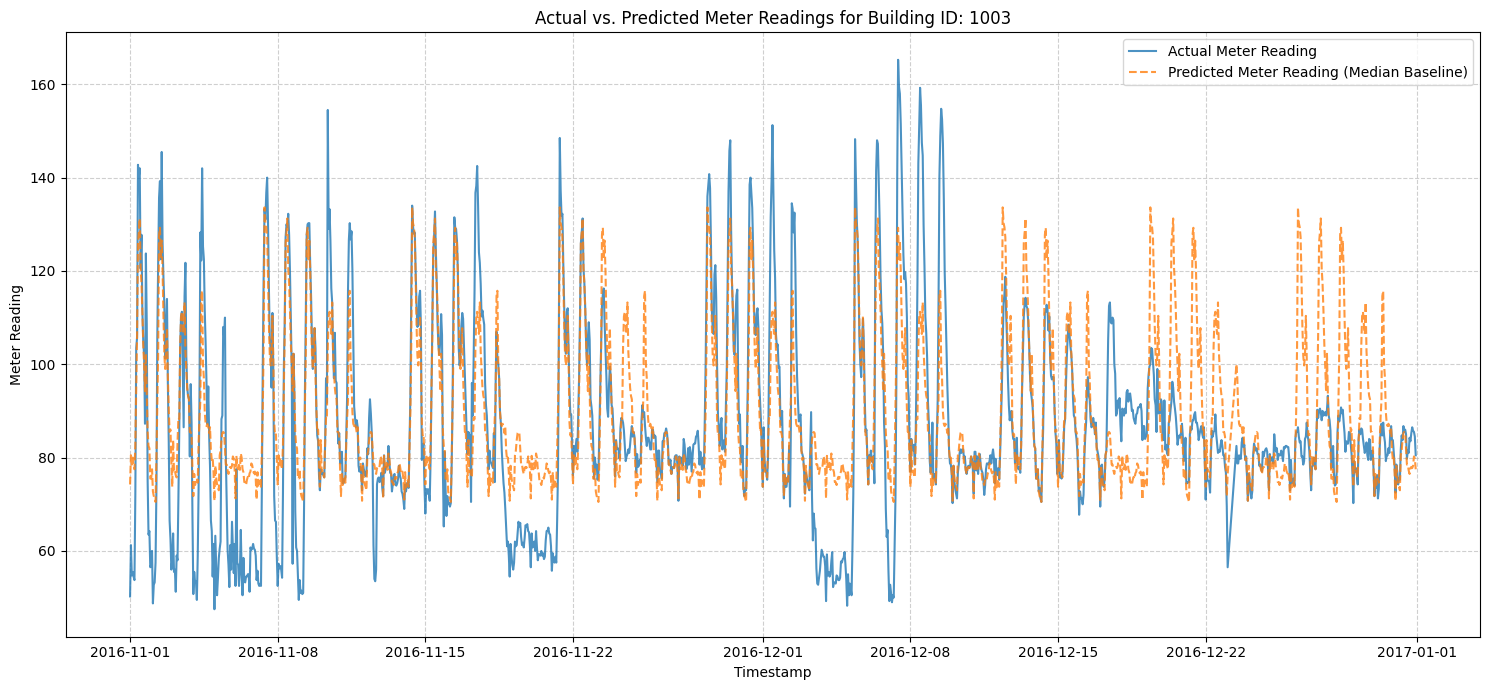

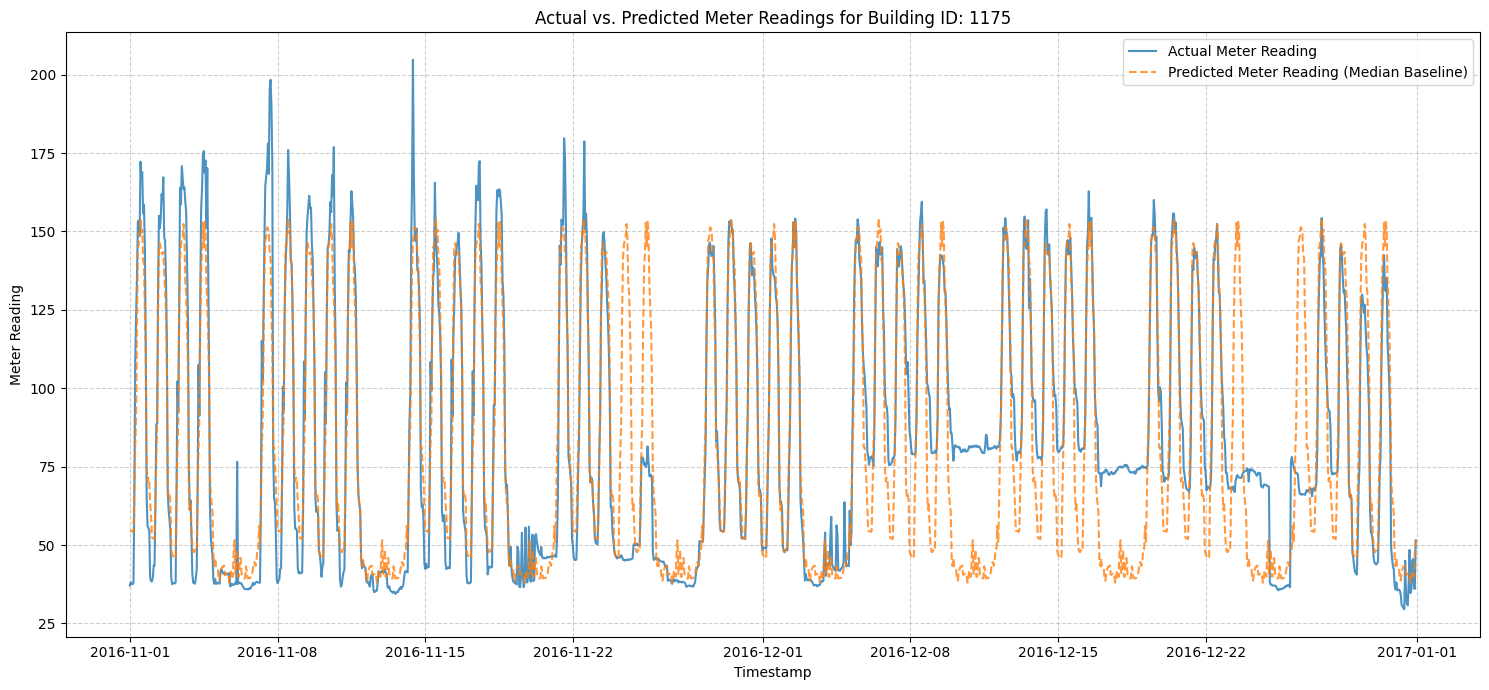

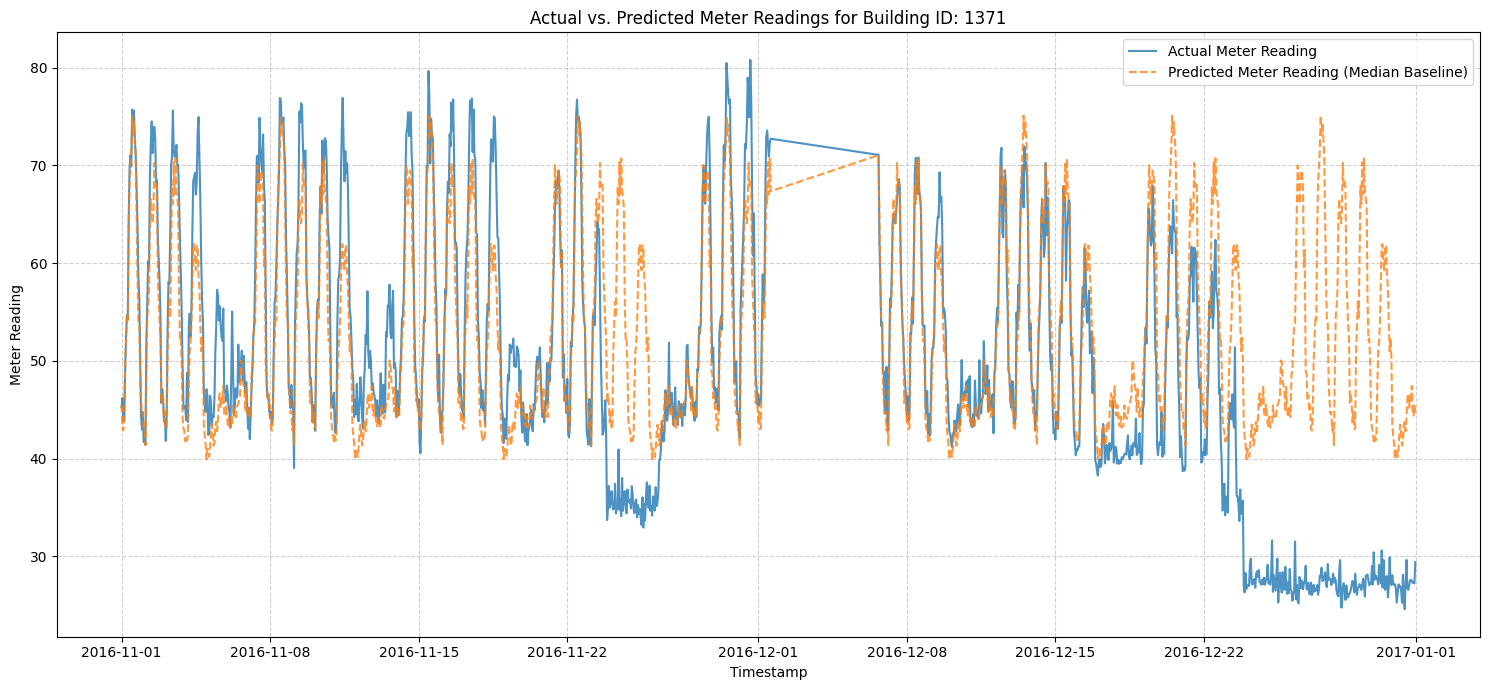

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get unique building_ids
unique_buildings = val_df['building_id'].unique()

# Select 3 random sample buildings (ensure there are at least 3 unique buildings)
num_samples = min(3, len(unique_buildings))
np.random.seed(42) # For reproducibility of sample selection
sample_buildings = np.random.choice(unique_buildings, num_samples, replace=False)

for building_id in sample_buildings:
    # Filter data for the current building
    building_df = val_df[val_df['building_id'] == building_id].copy()

    # Create the plot
    plt.figure(figsize=(15, 7))
    plt.plot(building_df['timestamp'], building_df['meter_reading_actual'], label='Actual Meter Reading', alpha=0.8)
    plt.plot(building_df['timestamp'], building_df['meter_reading_predicted'], label='Predicted Meter Reading (Median Baseline)', alpha=0.8, linestyle='--')

    plt.title(f'Actual vs. Predicted Meter Readings for Building ID: {building_id}')
    plt.xlabel('Timestamp')
    plt.ylabel('Meter Reading')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

---

## Sprint 3 — Random Forest Model Development & Tuning

---

## Sprint 4 — Evaluation & Report